# COVID-19 X-Ray Image Classification

Matej Herzog, Margaréta Strýčková

50/50

This notebook builds a Convolutional Neural Network (CNN) to classify chest X-ray images into three categories:
- **Covid** - COVID-19 positive cases
- **Normal** - Healthy patients
- **Viral Pneumonia** - Other viral pneumonia cases

## Workflow Overview
1. Download and explore the dataset
2. Convert images to grayscale and save locally
3. Create PyTorch data pipeline with stratified splits
4. Build and train a CNN model
5. Evaluate on test set

In [21]:
import kagglehub

In [22]:
# Download latest version
path = kagglehub.dataset_download("pranavraikokte/covid19-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\matej\.cache\kagglehub\datasets\pranavraikokte\covid19-image-dataset\versions\2


## 1. Exploratory Data Analysis (EDA)

We load the dataset and understand its structure - image dimensions, class distribution, and color channels.

In [23]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_style("whitegrid")

# Path from kagglehub download
dataset_root = Path(path)

# Find all images in the dataset
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
image_data = []

for root, dirs, files in os.walk(dataset_root):
    for file in files:
        if Path(file).suffix.lower() in image_extensions:
            file_path = Path(root) / file
            # Parent folder name = class label
            label = file_path.parent.name
            image_data.append({
                'path': str(file_path),
                'label': label,
                'filename': file
            })

df = pd.DataFrame(image_data)
print(f"Found {len(df)} images")
print("\nClass distribution:")
print(df['label'].value_counts())

Found 317 images

Class distribution:
label
Covid              137
Normal              90
Viral Pneumonia     90
Name: count, dtype: int64


**Simple Visualization of Images**

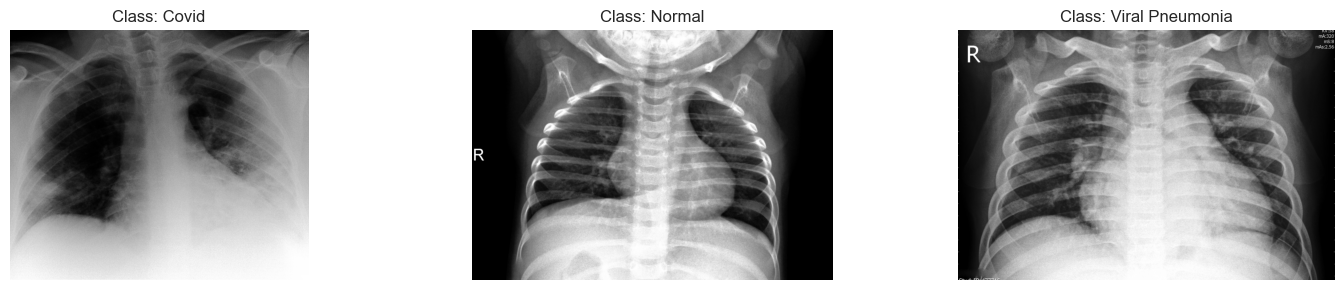

In [24]:
# Display one sample image from each class
unique_labels = df['label'].unique()
num_classes = len(unique_labels)

cols = min(5, num_classes)
rows = (num_classes + cols - 1) // cols

plt.figure(figsize=(15, 3 * rows))
for i, label in enumerate(unique_labels):
    if not df[df['label'] == label].empty:
        sample_row = df[df['label'] == label].sample(1).iloc[0]
        img_path = sample_row['path']
        
        try:
            with Image.open(img_path) as img:
                plt.subplot(rows, cols, i + 1)
                # Convert to numpy array to preserve original appearance
                img_array = np.array(img)
                # Display with gray colormap for grayscale images
                if len(img_array.shape) == 2 or img_array.shape[2] == 1:
                    plt.imshow(img_array, cmap='gray')
                else:
                    plt.imshow(img_array)
                plt.title(f"Class: {label}")
                plt.axis('off')
        except Exception as e:
            print(f"Error loading image for class {label}: {e}")

plt.tight_layout()
plt.show()

Average dimensions: 1625 x 1353
Min: 416x341, Max: 4248x4095


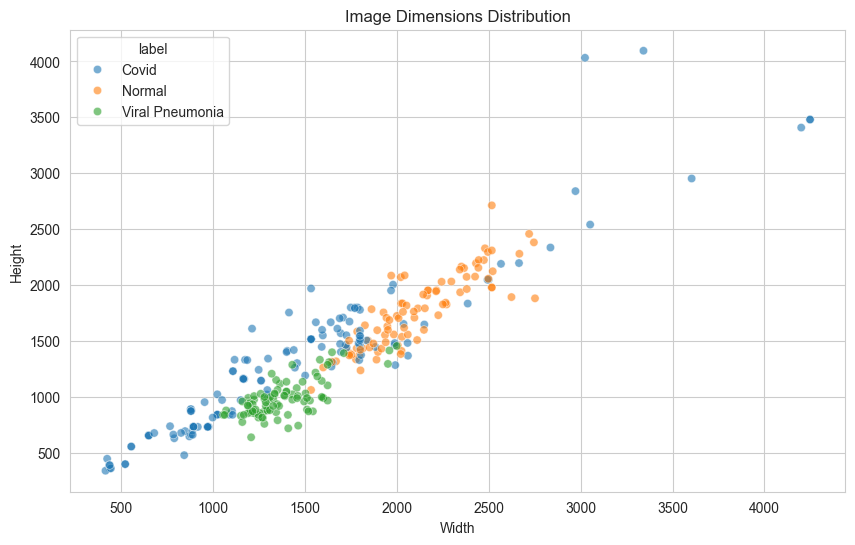

In [25]:
# Analyze image dimensions
widths = []
heights = []

for img_path in df['path']:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        pass

df['width'] = widths
df['height'] = heights

print(f"Average dimensions: {np.mean(widths):.0f} x {np.mean(heights):.0f}")
print(f"Min: {np.min(widths)}x{np.min(heights)}, Max: {np.max(widths)}x{np.max(heights)}")

# Plot dimension distribution by class
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='width', y='height', hue='label', alpha=0.6)
plt.title("Image Dimensions Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

The scatterplot illustrates the variability in input data quality.

- Dimensions range from low resolution (~400x300) to high resolution (~4000x4000).

- `Preprocessing Implication`: We must resize all images to a fixed size of `300x300` and convert them to `1 channel (Grayscale)`, thereby reducing computational complexity.

Images per class:
label
Covid              137
Normal              90
Viral Pneumonia     90
Name: count, dtype: int64


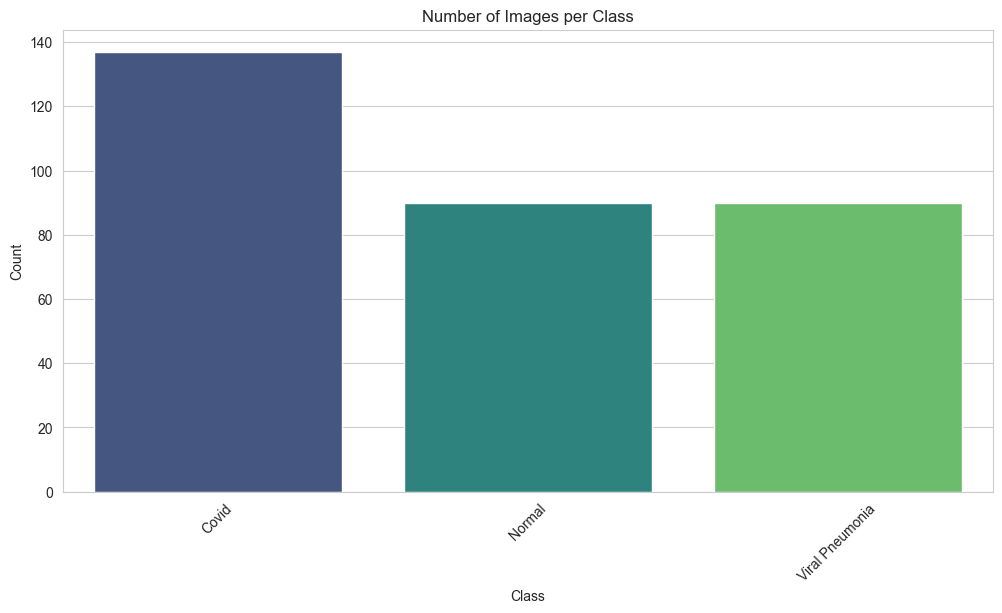

In [26]:
# Visualize class imbalance
class_counts = df['label'].value_counts()
print("Images per class:")
print(class_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, legend=False, palette='viridis')
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Label Distribution**

We can see that our dataset is not perfectly balanced, but it is manageable.
- **Class Distribution**:
  - Covid: 137 images
  - Normal: 90 images
  - Viral Pneumonia: 90 images

Color modes found:
mode
RGB     267
L        42
RGBA      8
Name: count, dtype: int64


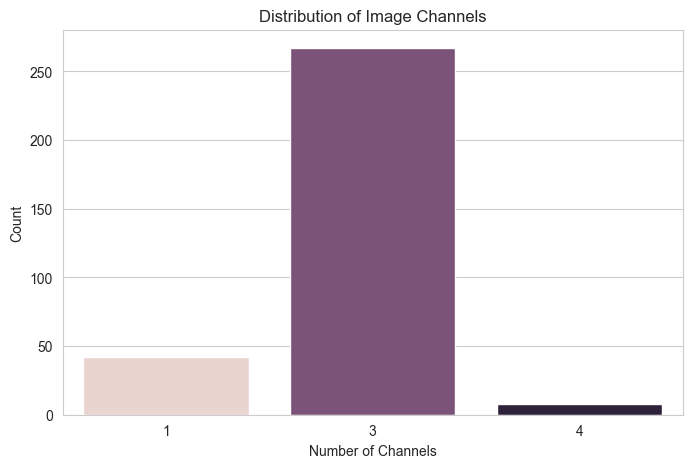

In [27]:
# Check color channels (RGB vs Grayscale)
modes = []
channels = []

for img_path in df['path']:
    try:
        with Image.open(img_path) as img:
            modes.append(img.mode)
            channels.append(len(img.getbands()))
    except:
        modes.append('Error')
        channels.append(0)

df['mode'] = modes
df['channels'] = channels

print("Color modes found:")
print(df['mode'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='channels', hue='channels', legend=False)
plt.title("Distribution of Image Channels")
plt.xlabel("Number of Channels")
plt.ylabel("Count")
plt.show()

**Analysis of Channels**
- Our images are mostly in RGB format (3 channels). However, chest X-rays are typically grayscale images.
- As our visualization suggests, we are probably dealing with gray-scale images stored in RGB format.
- We will convert all images to grayscale (1 channel) during preprocessing to simplify the model and reduce computational load.

## 2. Data Preprocessing

We convert all images to grayscale and save them locally. This standardizes the input and reduces complexity.

In [28]:
import shutil
from tqdm.notebook import tqdm

output_dir = Path('data')

# Clean and recreate output directory
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(parents=True)

print(f"Saving grayscale images to: {output_dir.absolute()}")

# Convert each image to grayscale and save
unique_labels = df['label'].unique()

for label in unique_labels:
    class_dir = output_dir / label
    class_dir.mkdir(exist_ok=True)
    
    class_images = df[df['label'] == label]
    print(f"Processing: {label}")
    
    for i, (_, row) in enumerate(tqdm(class_images.iterrows(), total=len(class_images), desc=label)):
        try:
            with Image.open(row['path']) as img:
                gray_img = img.convert('L')  # Convert to grayscale
                new_filename = f"{label}_{i+1:04d}.png"
                gray_img.save(class_dir / new_filename)
        except Exception as e:
            print(f"Error: {row['path']}: {e}")

print("\nConversion complete!")

# Verify the new dataset
new_image_data = []
for root, dirs, files in os.walk(output_dir):
    for file in files:
        if file.endswith('.png'):
            file_path = Path(root) / file
            label = file_path.parent.name
            new_image_data.append({'path': str(file_path), 'label': label, 'filename': file})

new_df = pd.DataFrame(new_image_data)
print(f"Created {len(new_df)} grayscale images")
print(new_df['label'].value_counts())

Saving grayscale images to: c:\Users\matej\Nextcloud\FIIT\Semester 5\IAU\covid_dataset\data
Processing: Covid


Covid:   0%|          | 0/137 [00:00<?, ?it/s]

Processing: Normal


Normal:   0%|          | 0/90 [00:00<?, ?it/s]

Processing: Viral Pneumonia


Viral Pneumonia:   0%|          | 0/90 [00:00<?, ?it/s]


Conversion complete!
Created 317 grayscale images
label
Covid              137
Normal              90
Viral Pneumonia     90
Name: count, dtype: int64


Verify all images are now single-channel grayscale

In [29]:

grayscale_image_data = []
output_dir = Path('data')

for root, dirs, files in os.walk(output_dir):
    for file in files:
        if file.endswith('.png'):
            file_path = Path(root) / file
            label = file_path.parent.name
            grayscale_image_data.append({'path': str(file_path), 'label': label, 'filename': file})

df_grayscale = pd.DataFrame(grayscale_image_data)

# Check channels
modes = []
channels = []
for img_path in tqdm(df_grayscale['path'], desc="Verifying"):
    try:
        with Image.open(img_path) as img:
            modes.append(img.mode)
            channels.append(len(img.getbands()))
    except:
        modes.append('Error')
        channels.append(0)

df_grayscale['mode'] = modes
df_grayscale['channels'] = channels

print("Grayscale dataset verification:")
print(df_grayscale['mode'].value_counts())

Verifying:   0%|          | 0/317 [00:00<?, ?it/s]

Grayscale dataset verification:
mode
L    317
Name: count, dtype: int64


We display a random sample of 6 grayscale images from each class to verify that the conversion was successful and the image content remains clear.

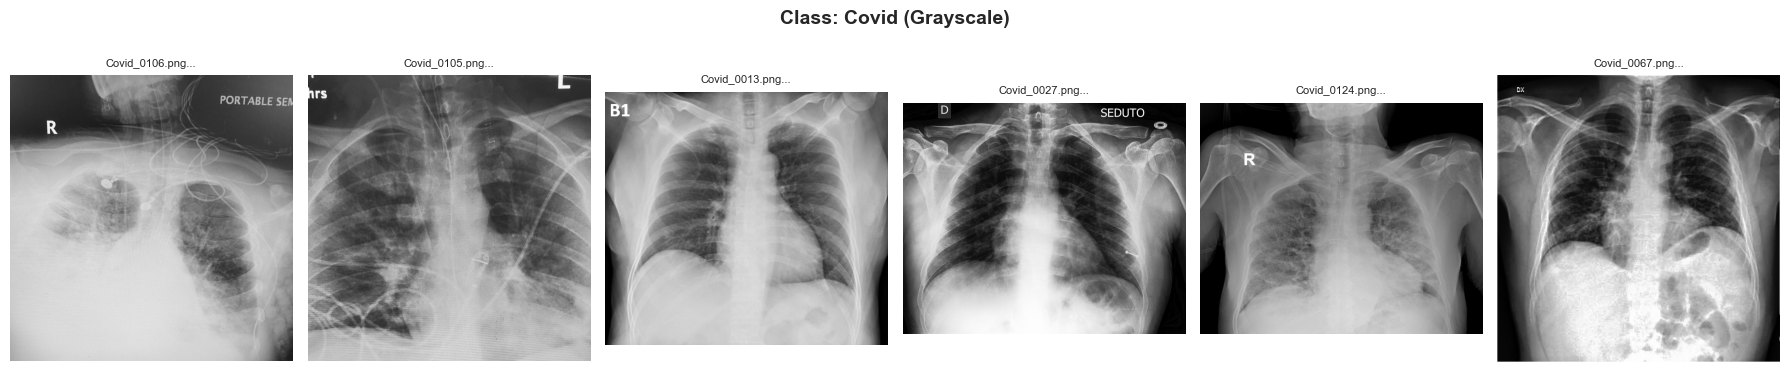

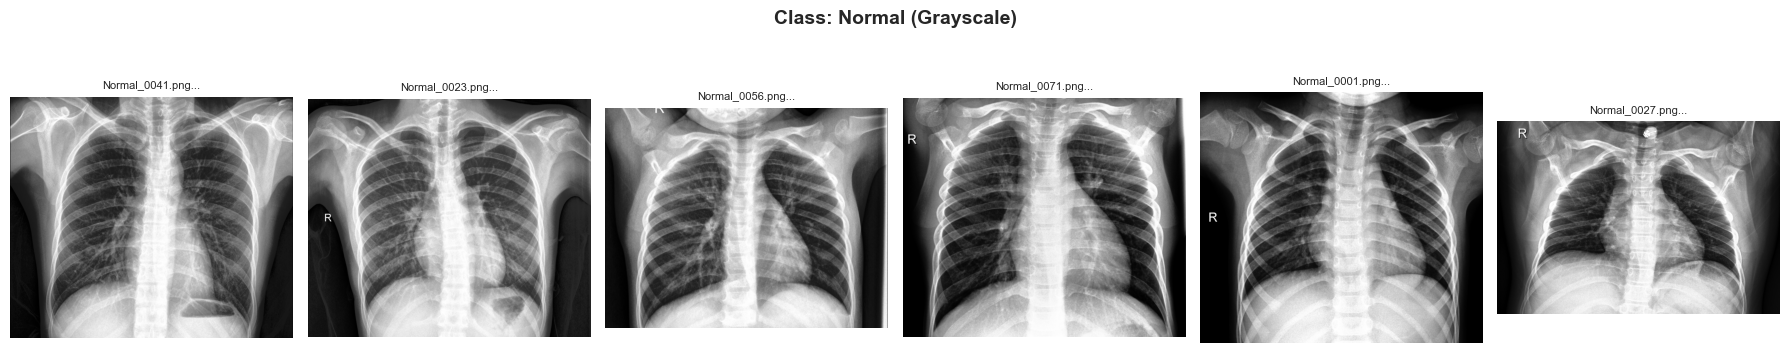

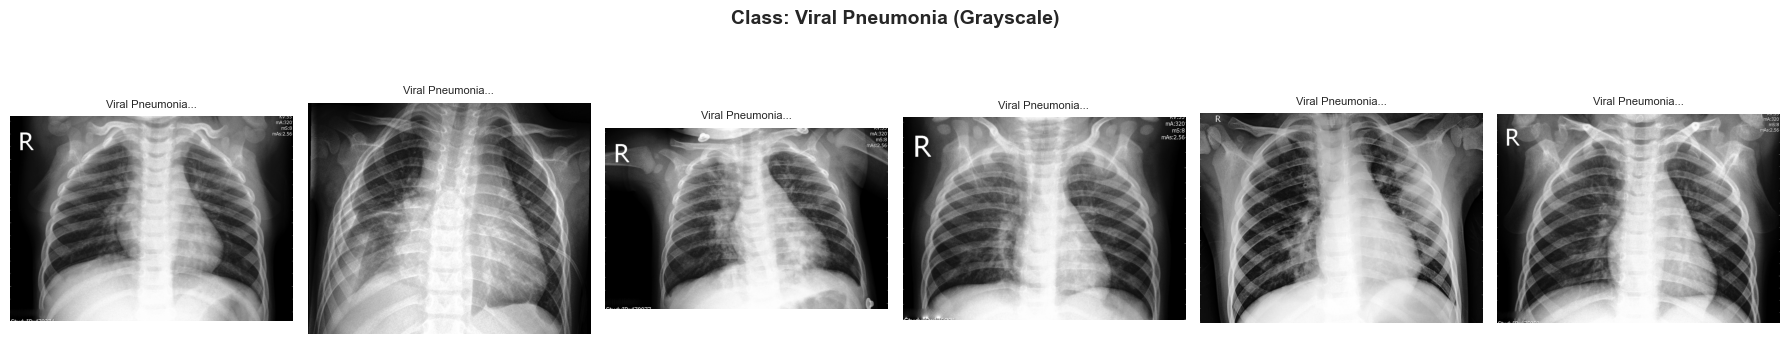

In [ ]:
# Display sample grayscale images, 6 per class
unique_labels = df_grayscale['label'].unique()
samples_per_class = 6

for label in unique_labels:
    class_images = df_grayscale[df_grayscale['label'] == label]
    
    # Sample up to 6 images from the class
    n_samples = min(samples_per_class, len(class_images))
    samples = class_images.sample(n_samples, random_state=42)
    
    # Create subplot grid
    cols = min(6, n_samples)
    rows = 1
    
    plt.figure(figsize=(3 * cols, 4))
    plt.suptitle(f'Class: {label} (Grayscale)', fontsize=14, fontweight='bold')
    
    for i, (_, row) in enumerate(samples.iterrows()):
        plt.subplot(rows, cols, i + 1)
        
        try:
            with Image.open(row['path']) as img:
                plt.imshow(img, cmap='gray')
                plt.title(f"{row['filename'][:15]}...", fontsize=8)
                plt.axis('off')
        except Exception as e:
            print(f"Error loading {row['path']}: {e}")
    
    plt.tight_layout()
    plt.show()


## 3. PyTorch Data Pipeline

We set up the data loading pipeline:
1. Load images with basic transforms
2. Split into train/val/test (70/20/10) with stratification
3. Calculate normalization statistics from training data only
4. Apply normalization and create DataLoaders

In [31]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from collections import Counter

# Hyperparameters
IMAGE_SIZE = (300, 300)
BATCH_SIZE = 32
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

# Basic transforms (no normalization yet - we need to calculate stats first)
basic_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
])

# Load dataset using ImageFolder 
dataset = datasets.ImageFolder(root='data', transform=basic_transforms)

print(f"Classes: {dataset.classes}")
print(f"Total images: {len(dataset)}")

# Stratified split to maintain class distribution
targets = np.array(dataset.targets)

# First split: train vs (val + test)
train_indices, temp_indices = train_test_split(
    np.arange(len(targets)),
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=targets,
    random_state=42
)

# Second split: val vs test
temp_targets = targets[temp_indices]
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=(TEST_RATIO / (VAL_RATIO + TEST_RATIO)),
    stratify=temp_targets,
    random_state=42
)

# Create subsets
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

print(f"\nSplit sizes:")
print(f"  Train: {len(train_dataset)} ({len(train_dataset)/len(dataset)*100:.1f}%)")
print(f"  Val:   {len(val_dataset)} ({len(val_dataset)/len(dataset)*100:.1f}%)")
print(f"  Test:  {len(test_dataset)} ({len(test_dataset)/len(dataset)*100:.1f}%)")

Classes: ['Covid', 'Normal', 'Viral Pneumonia']
Total images: 317

Split sizes:
  Train: 221 (69.7%)
  Val:   64 (20.2%)
  Test:  32 (10.1%)


We compute the mean and standard deviation specifically from the **training set** to normalize our data. This ensures that information from the validation or test sets does not influence the training process (preventing data leakage).

In [32]:
def calculate_mean_std(loader):
    """Calculate channel-wise mean and std."""
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    
    for data, _ in tqdm(loader, desc="Calculating stats"):
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data ** 2, dim=[0, 2, 3])
        num_batches += 1
    
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean ** 2) ** 0.5
    return mean, std

train_loader_for_stats = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
MEAN, STD = calculate_mean_std(train_loader_for_stats)

print(f"Normalization stats (from training data):")
print(f"  Mean: {MEAN.item():.4f}")
print(f"  Std:  {STD.item():.4f}")

Calculating stats:   0%|          | 0/7 [00:00<?, ?it/s]

Normalization stats (from training data):
  Mean: 0.4962
  Std:  0.2807


We define the complete transformation pipeline, incorporating the normalization statistics (`MEAN` and `STD`) calculated in the previous step. We then generate PyTorch `DataLoaders` to handle batching and shuffling, and finally verify that the processed data batches are correctly standardized.

In [33]:
final_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Update dataset transforms
dataset.transform = final_transforms

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verify normalization
sample_batch, _ = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Batch mean: {sample_batch.mean():.4f} (should be ~0)")
print(f"Batch std:  {sample_batch.std():.4f} (should be ~1)")

Batch shape: torch.Size([32, 1, 300, 300])
Batch mean: 0.0093 (should be ~0)
Batch std:  1.0147 (should be ~1)


In [34]:
# Class mapping summary
NUM_CLASSES = len(dataset.classes)

print("Class Mapping:")
for class_name, class_idx in dataset.class_to_idx.items():
    print(f"  {class_idx} -> {class_name}")
print(f"\nNumber of classes: {NUM_CLASSES}")

Class Mapping:
  0 -> Covid
  1 -> Normal
  2 -> Viral Pneumonia

Number of classes: 3


## 4. CNN Model Architecture

A simple CNN with 3 convolutional blocks followed by fully connected layers:
- Conv blocks: Conv2D → BatchNorm → ReLU → MaxPool
- FC layers: Linear → ReLU → Dropout → Linear (output)

In [35]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        # Conv Block 1: 1 -> 32 channels, 300x300 -> 150x150
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Conv Block 2: 32 -> 64 channels, 150x150 -> 75x75
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Conv Block 3: 64 -> 128 channels, 75x75 -> 37x37
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Adaptive pooling ensures fixed output size (128 x 4 x 4)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Conv blocks with ReLU activation
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        
        # Flatten and FC layers
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
print(model)

Using device: cpu
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=3, bi

## 5. Training and Evaluation Functions

Helper functions for training, evaluation, and visualization.

In [36]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix

def calculate_metrics(y_true, y_pred):
    """Calculate classification metrics."""
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch and return metrics."""
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': loss.item()})
    
    metrics = calculate_metrics(all_targets, all_preds)
    metrics['loss'] = running_loss / len(loader.dataset)
    return metrics

def evaluate_model(model, loader, criterion, device, desc="Validation"):
    """Evaluate model and return metrics with predictions."""
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
    
    metrics = calculate_metrics(all_targets, all_preds)
    metrics['loss'] = running_loss / len(loader.dataset)
    metrics['targets'] = all_targets
    metrics['predictions'] = all_preds
    return metrics

In [37]:
def plot_training_history(history, best_val_cm_data=None, classes=None, best_epoch=None):
    """Plot training curves and confusion matrix with best model epoch highlighted."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    def plot_metric(ax, train_key, val_key, title, ylabel):
        ax.plot(epochs, history[train_key], label='Train', marker='o', markersize=3)
        ax.plot(epochs, history[val_key], label='Val', marker='s', markersize=3)
        
        # Highlight best epoch
        if best_epoch is not None and best_epoch <= len(history[val_key]):
            best_val_value = history[val_key][best_epoch - 1]
            ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
            ax.scatter([best_epoch], [best_val_value], color='red', s=100, zorder=5, edgecolors='black', linewidths=1.5)
            ax.annotate('Selected Model', 
                       xy=(best_epoch, best_val_value), 
                       xytext=(10, 10), 
                       textcoords='offset points',
                       fontsize=9,
                       color='red',
                       fontweight='bold',
                       arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
        
        ax.set_title(title)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True)
    
    plot_metric(axes[0, 0], 'train_loss', 'val_loss', 'Loss', 'Loss')
    plot_metric(axes[0, 1], 'train_accuracy', 'val_accuracy', 'Accuracy', 'Accuracy')
    plot_metric(axes[0, 2], 'train_f1', 'val_f1', 'F1 Score', 'F1')
    plot_metric(axes[1, 0], 'train_precision', 'val_precision', 'Precision', 'Precision')
    plot_metric(axes[1, 1], 'train_recall', 'val_recall', 'Recall', 'Recall')
    
    # Confusion matrix
    if best_val_cm_data is not None and classes is not None:
        y_true, y_pred = best_val_cm_data
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=classes, yticklabels=classes, ax=axes[1, 2])
        axes[1, 2].set_title(f'Best Val Confusion Matrix (Epoch {best_epoch})' if best_epoch else 'Best Val Confusion Matrix')
        axes[1, 2].set_ylabel('True')
        axes[1, 2].set_xlabel('Predicted')
    else:
        axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    """Plot standalone confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

def plot_metrics_barplot(metrics_dict, title="Metrics"):
    """Plot metrics as bar chart."""
    metrics_to_plot = {k: v for k, v in metrics_dict.items() if k not in ['targets', 'predictions']}
    df = pd.DataFrame({'Metric': list(metrics_to_plot.keys()), 'Score': list(metrics_to_plot.values())})
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Metric', y='Score', data=df, hue='Metric', palette='viridis', legend=False)
    plt.title(title)
    plt.ylim(0, max(1.1, df['Score'].max() + 0.1))
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
    plt.show()

## 6. Baseline Training Loop

Train the model with early stopping based on validation performance.

Training with early stopping (metric: accuracy, patience: 15)

Epoch 1/50


Training:   0%|          | 0/7 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Train - Loss: 1.0670, Acc: 0.5249, F1: 0.5179
Val   - Loss: 0.8143, Acc: 0.7500, F1: 0.7140
  -> New best accuracy: 0.7500. Model saved.

Epoch 2/50


Training:   0%|          | 0/7 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Train - Loss: 0.0383, Acc: 0.9910, F1: 0.9909
Val   - Loss: 0.2202, Acc: 0.9531, F1: 0.9520
  -> No improvement for 14 epoch(s).

Epoch 32/50


Training:   0%|          | 0/7 [00:00<?, ?it/s]

Validation:   0%|          | 0/2 [00:00<?, ?it/s]

Train - Loss: 0.0831, Acc: 0.9729, F1: 0.9728
Val   - Loss: 0.1462, Acc: 0.9531, F1: 0.9530
  -> No improvement for 15 epoch(s).
Early stopping triggered!

Training complete!
Best model from epoch 17


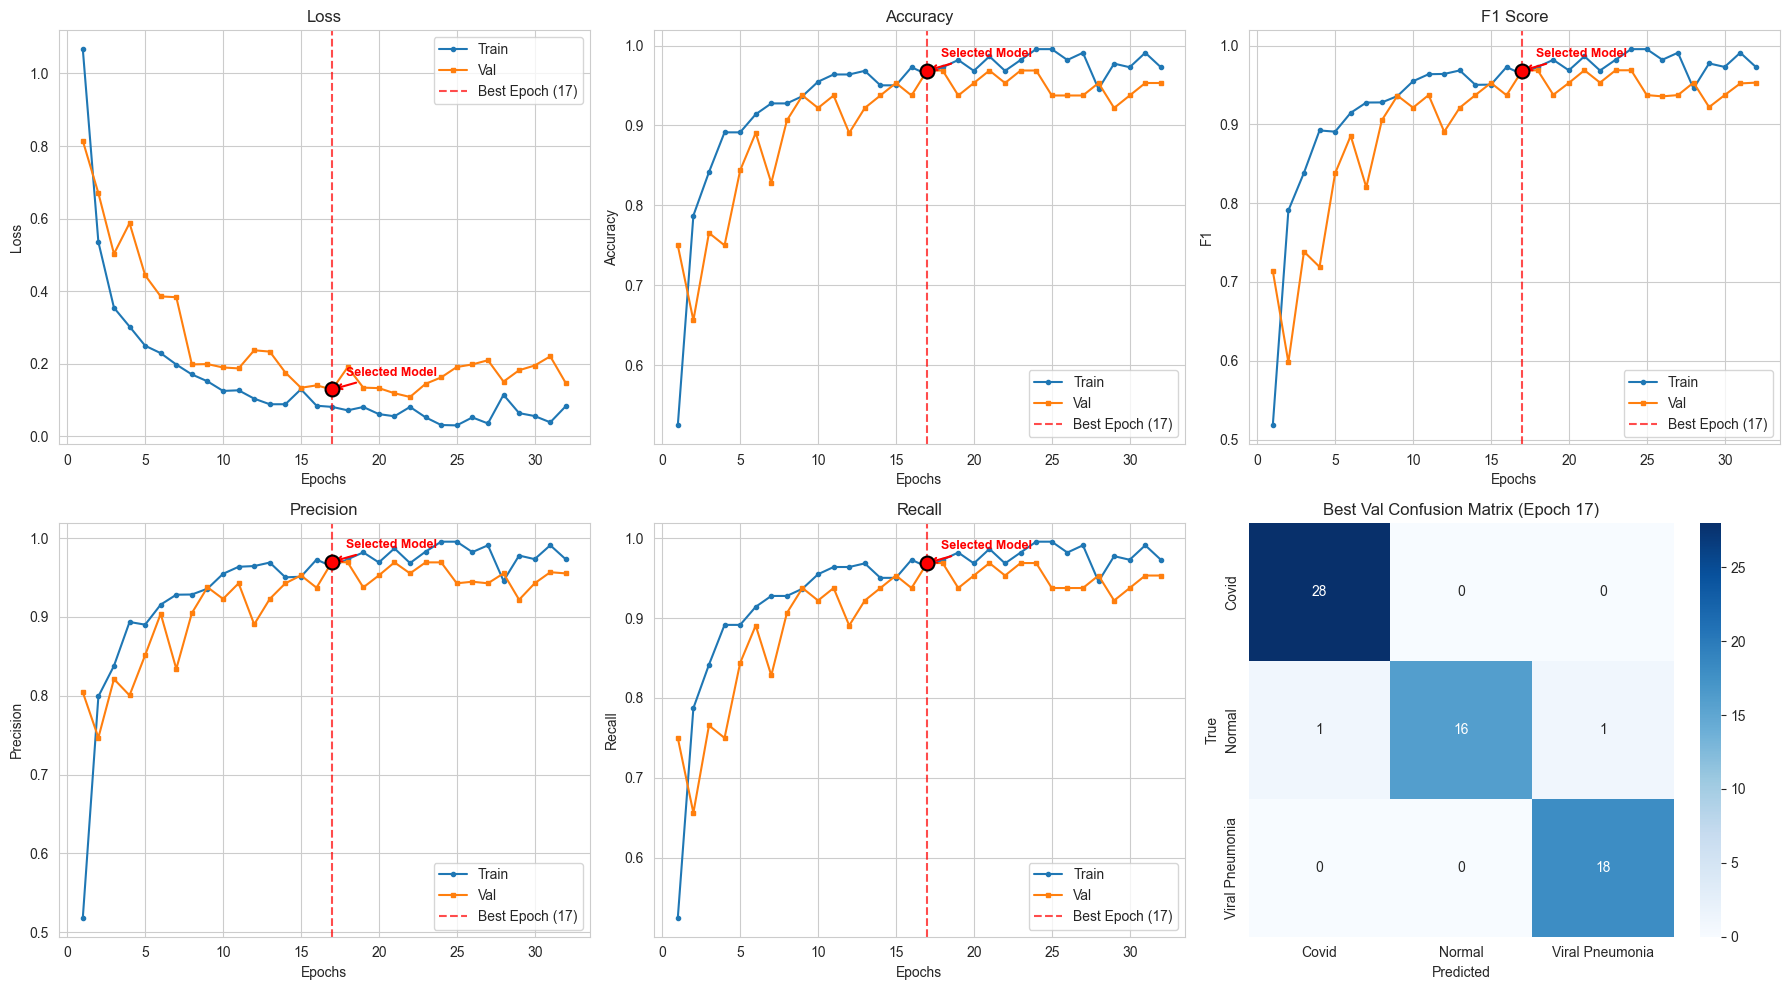

In [38]:
import copy
import torch.optim as optim

# Training hyperparameters
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
PATIENCE = 15
EARLY_STOP_METRIC = 'accuracy'  # Options: 'loss', 'accuracy', 'f1', 'precision', 'recall'

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Track training history
history = {
    'train_loss': [], 'train_accuracy': [], 'train_precision': [], 'train_recall': [], 'train_f1': [],
    'val_loss': [], 'val_accuracy': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
}

# Early stopping setup
best_metric_value = float('inf') if EARLY_STOP_METRIC == 'loss' else float('-inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())
best_val_cm_data = None
best_epoch = None  # Track the best epoch

def is_better(current, best, metric_name):
    """Check if current metric is better (lower for loss, higher for others)."""
    return current < best if metric_name == 'loss' else current > best

print(f"Training with early stopping (metric: {EARLY_STOP_METRIC}, patience: {PATIENCE})")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate_model(model, val_loader, criterion, device)
    
    # Store metrics
    for key in ['loss', 'accuracy', 'precision', 'recall', 'f1']:
        history[f'train_{key}'].append(train_metrics[key])
        history[f'val_{key}'].append(val_metrics[key])
    
    print(f"Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, F1: {train_metrics['f1']:.4f}")
    print(f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, F1: {val_metrics['f1']:.4f}")
    
    # Early stopping check
    current_metric = val_metrics[EARLY_STOP_METRIC]
    
    if is_better(current_metric, best_metric_value, EARLY_STOP_METRIC):
        best_metric_value = current_metric
        best_model_wts = copy.deepcopy(model.state_dict())
        best_val_cm_data = (val_metrics['targets'], val_metrics['predictions'])
        best_epoch = epoch + 1  # Store best epoch (1-indexed)
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  -> New best {EARLY_STOP_METRIC}: {current_metric:.4f}. Model saved.")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered!")
            break

print("\nTraining complete!")
print(f"Best model from epoch {best_epoch}")
model.load_state_dict(best_model_wts)
plot_training_history(history, best_val_cm_data, dataset.classes, best_epoch=best_epoch)

The training process was configured for a maximum of 50 epochs with a Learning Rate of `0.001`. A key mechanism was `Early Stopping` with a patience of `15 epochs`, which monitored the `accuracy` metric on the validation set.

Training Curves:

- Loss: Training loss consistently decreases, indicating the model is learning. Validation loss also decreases, but after epoch 17, model starts to be overtrained. Without any gains in validation accuracy, early stopping halts training at epoch 32.

- Accuracy: The model quickly achieved high performance, exceeding 90% accuracy on the validation set after epoch 8.

- Overfitting: There is a slight generalization gap between the training and validation curves, but it is normal, our model performs slightly better on the training set. We have used dropout and batch normalization to mitigate overfitting.

The Best Model was achieved at Epoch 17.

Subsequent epochs (18-32) showed no improvement over the peak validation accuracy of 0.9688.

## 6.1. Test Set Evaluation (Initial Model)

Evaluate the initial trained model on the test set.

Testing Initial Model:   0%|          | 0/1 [00:00<?, ?it/s]

INITIAL MODEL - TEST SET RESULTS
   Metric    Score
     Loss 0.093392
 Accuracy 0.937500
Precision 0.948864
   Recall 0.937500
 F1 Score 0.939127


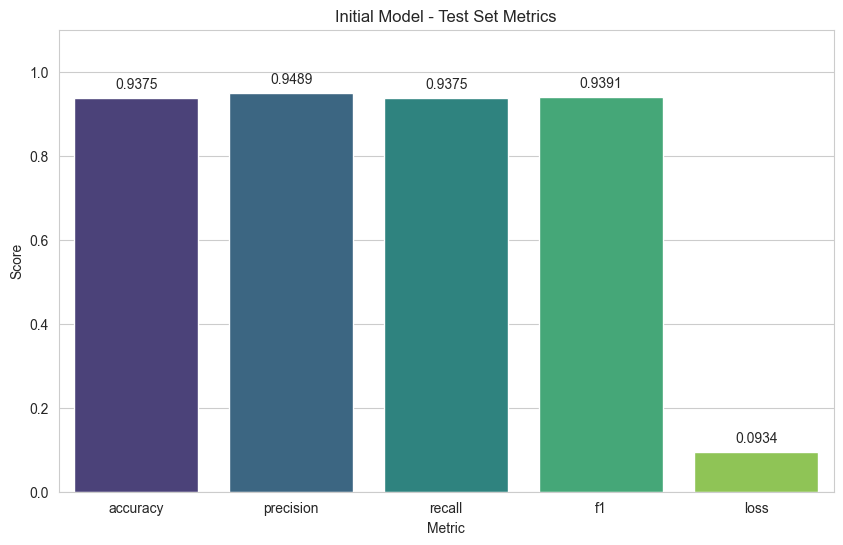

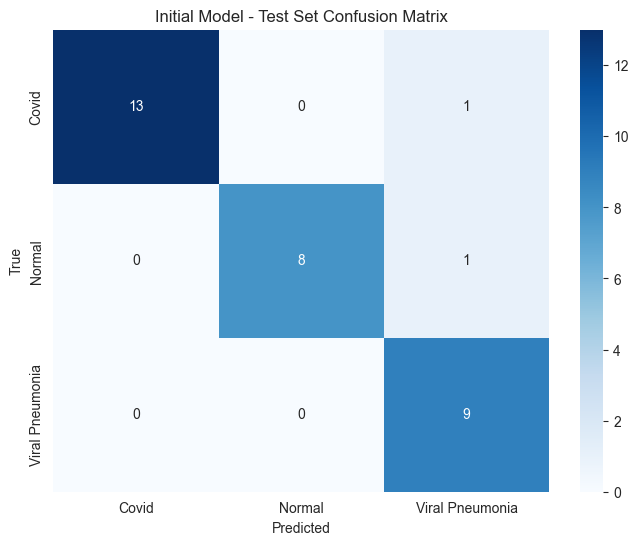

In [39]:
# Evaluate initial model on test set
initial_test_metrics = evaluate_model(model, test_loader, criterion, device, desc="Testing Initial Model")

# Display results
initial_results_df = pd.DataFrame({
    'Metric': ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [initial_test_metrics['loss'], initial_test_metrics['accuracy'], 
              initial_test_metrics['precision'], initial_test_metrics['recall'], initial_test_metrics['f1']]
})

print("="*50)
print("INITIAL MODEL - TEST SET RESULTS")
print("="*50)
print(initial_results_df.to_string(index=False))
print("="*50)

plot_metrics_barplot(initial_test_metrics, title="Initial Model - Test Set Metrics")
plot_confusion_matrix(initial_test_metrics['targets'], initial_test_metrics['predictions'], 
                      dataset.classes, title="Initial Model - Test Set Confusion Matrix")

**Our baseline model achieved initial Test Accuracy of 0.9375.**

## 6.2. Combined Validation + Test Evaluation (Initial Model)

Evaluate the initial model on both validation and test sets combined for a comprehensive assessment.

Combined evaluation set size: 96
  - Validation samples: 64
  - Test samples: 32


Combined Eval:   0%|          | 0/3 [00:00<?, ?it/s]


INITIAL MODEL - COMBINED VAL + TEST RESULTS
   Metric    Score
     Loss 0.117053
 Accuracy 0.958333
Precision 0.961458
   Recall 0.958333
 F1 Score 0.958237

Comparison:
   Metric  Test Only  Combined
 Accuracy   0.937500  0.958333
Precision   0.948864  0.961458
   Recall   0.937500  0.958333
       F1   0.939127  0.958237


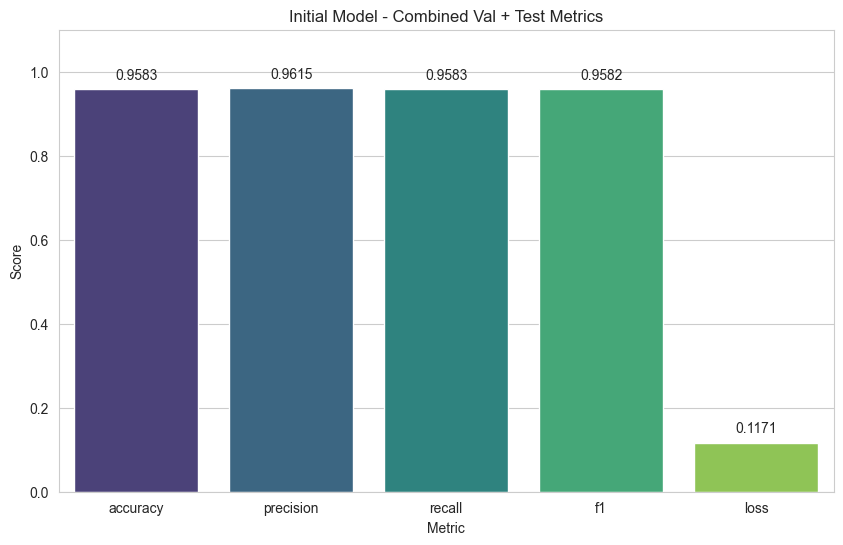

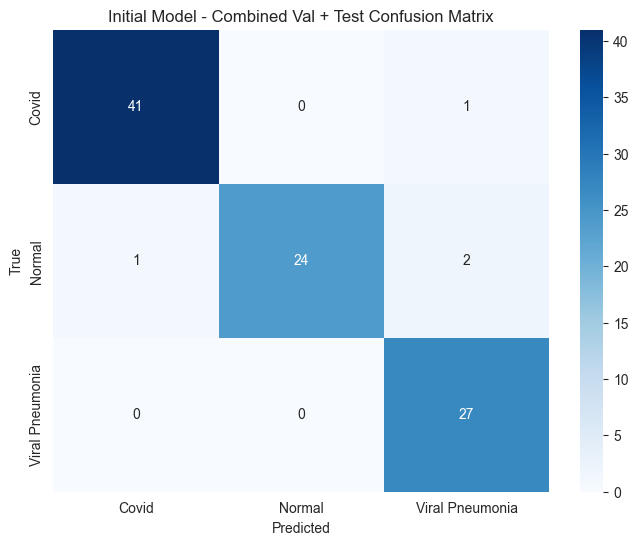

In [40]:
# Combine validation and test data for comprehensive evaluation
from torch.utils.data import ConcatDataset

# Create combined dataset and loader
initial_combined_dataset = ConcatDataset([val_dataset, test_dataset])
initial_combined_loader = DataLoader(initial_combined_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Combined evaluation set size: {len(initial_combined_dataset)}")
print(f"  - Validation samples: {len(val_dataset)}")
print(f"  - Test samples: {len(test_dataset)}")

# Evaluate best model on combined data
initial_combined_metrics = evaluate_model(model, initial_combined_loader, criterion, device, desc="Combined Eval")

# Display results
initial_combined_results_df = pd.DataFrame({
    'Metric': ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [initial_combined_metrics['loss'], initial_combined_metrics['accuracy'], 
              initial_combined_metrics['precision'], initial_combined_metrics['recall'], initial_combined_metrics['f1']]
})

print("\n" + "="*50)
print("INITIAL MODEL - COMBINED VAL + TEST RESULTS")
print("="*50)
print(initial_combined_results_df.to_string(index=False))
print("="*50)

# Compare with test only
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'Test Only': [initial_test_metrics['accuracy'], initial_test_metrics['precision'], 
                  initial_test_metrics['recall'], initial_test_metrics['f1']],
    'Combined': [initial_combined_metrics['accuracy'], initial_combined_metrics['precision'], 
                 initial_combined_metrics['recall'], initial_combined_metrics['f1']]
})
print("\nComparison:")
print(comparison_df.to_string(index=False))

# Visualizations
plot_metrics_barplot(initial_combined_metrics, title="Initial Model - Combined Val + Test Metrics")
plot_confusion_matrix(initial_combined_metrics['targets'], initial_combined_metrics['predictions'], 
                      dataset.classes, title="Initial Model - Combined Val + Test Confusion Matrix")

## 7. Hyperparameter optimization
First, we redefine SimpleCNN to accept dropout_rate and start_filters as arguments.

In [20]:
import torch.nn as nn
import torch.nn.functional as F

# Modified class to accept hyperparameters
class TunableCNN(nn.Module):
    def __init__(self, num_classes, start_filters=32, dropout_rate=0.5):
        super(TunableCNN, self).__init__()
        
        self.start_filters = start_filters
        
        # Conv Block 1: 1 -> start_filters
        self.conv1 = nn.Conv2d(1, start_filters, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(start_filters)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Conv Block 2: start_filters -> start_filters*2
        self.conv2 = nn.Conv2d(start_filters, start_filters*2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(start_filters*2)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Conv Block 3: start_filters*2 -> start_filters*4
        self.conv3 = nn.Conv2d(start_filters*2, start_filters*4, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(start_filters*4)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Adaptive pooling
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        # Fully connected layers
        # Input size depends on the last conv layer: (start_filters*4) * 4 * 4
        self.fc1 = nn.Linear((start_filters*4) * 4 * 4, 512)
        self.dropout = nn.Dropout(dropout_rate) # Dynamic Dropout
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Conv blocks
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        
        # Flatten and FC layers
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

Random Search Loop

In [ ]:
import random
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Define the Hyperparameter Search Space
param_grid = {
    'lr': [0.001, 0.0005, 0.0001],
    'dropout': [0.3, 0.4, 0.5, 0.6],
    'batch_size': [16, 32],
    'start_filters': [16, 32, 64]
}

# 2. Settings for the Search
NUM_SEARCH_ITERATIONS = 20 # combinations
SEARCH_EPOCHS = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_val_acc = 0.0
best_params = {}
best_model_state = None

print(f"Starting Random Search for {NUM_SEARCH_ITERATIONS} iterations...")
print("-" * 60)

for i in range(NUM_SEARCH_ITERATIONS):
    # Randomly Sample Hyperparameters
    params = {
        'lr': random.choice(param_grid['lr']),
        'dropout': random.choice(param_grid['dropout']),
        'batch_size': random.choice(param_grid['batch_size']),
        'start_filters': random.choice(param_grid['start_filters'])
    }
    
    print(f"\nIteration {i+1}/{NUM_SEARCH_ITERATIONS} | Testing params: {params}")
    
    # Prepare DataLoaders with sampled Batch Size
    train_loader_tune = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
    val_loader_tune = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False)
    
    # Initialize Model with sampled architecture params
    model = TunableCNN(num_classes=3, 
                       start_filters=params['start_filters'], 
                       dropout_rate=params['dropout']).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=params['lr'])
    
    # Short Training Loop
    for epoch in range(SEARCH_EPOCHS):
        train_metrics = train_one_epoch(model, train_loader_tune, criterion, optimizer, device)
        val_metrics = evaluate_model(model, val_loader_tune, criterion, device, desc="Val")
        
    print(f"  -> Result: Val Acc: {val_metrics['accuracy']:.4f} | Loss: {val_metrics['loss']:.4f}")
    
    # Check if this is the best model so far
    if val_metrics['accuracy'] > best_val_acc:
        best_val_acc = val_metrics['accuracy']
        best_params = params
        best_model_state = model.state_dict()
        print("  *** New Best Parameter Set Found! ***")

print("\n" + "=" * 60)
print("HYPERPARAMETER OPTIMIZATION FINISHED")
print("=" * 60)
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Hyperparameters: {best_params}")

Starting Random Search for 20 iterations...
------------------------------------------------------------

Iteration 1/20 | Testing params: {'lr': 0.0005, 'dropout': 0.5, 'batch_size': 32, 'start_filters': 32}


Training:   0%|          | 0/7 [00:00<?, ?it/s]

Val:   0%|          | 0/2 [00:00<?, ?it/s]

Training:   0%|          | 0/7 [00:00<?, ?it/s]

Val:   0%|          | 0/2 [00:00<?, ?it/s]

...

Training:   0%|          | 0/7 [00:00<?, ?it/s]

Val:   0%|          | 0/2 [00:00<?, ?it/s]

Training:   0%|          | 0/7 [00:00<?, ?it/s]

Val:   0%|          | 0/2 [00:00<?, ?it/s]

  -> Result: Val Acc: 0.9219 | Loss: 0.2108

HYPERPARAMETER OPTIMIZATION FINISHED
Best Validation Accuracy: 0.9688
Best Hyperparameters: {'lr': 0.0005, 'dropout': 0.4, 'batch_size': 16, 'start_filters': 32}


Hyperparameter Optimization Results: 
We executed a Random Search over 20 iterations to identify the most effective hyperparameter combination. The process yielded an optimal configuration (Learning Rate: 0.0005, Dropout: 0.4, Batch Size: 16) that achieved a `Validation Accuracy of 96.88%`, which we will now use for the final full training run.


SPÚŠŤAM FINÁLNY TRÉNING S NAJLEPŠÍMI PARAMETRAMI
Konfigurácia: {'lr': 0.0005, 'dropout': 0.4, 'batch_size': 16, 'start_filters': 32}
Training initialized with early stopping (metric: accuracy, patience: 15)...

Epoch 1/50


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Val:   0%|          | 0/4 [00:00<?, ?it/s]

Train - Loss: 0.8721, Acc: 0.6425, F1: 0.6448
Val   - Loss: 0.6216, Acc: 0.6562, F1: 0.5478
  -> New best accuracy: 0.6562. Model saved.

Epoch 2/50


Training:   0%|          | 0/14 [00:00<?, ?it/s]

...

Val:   0%|          | 0/4 [00:00<?, ?it/s]

Train - Loss: 0.0326, Acc: 0.9910, F1: 0.9910
Val   - Loss: 0.0943, Acc: 0.9688, F1: 0.9687
  -> No improvement for 14 epoch(s).

Epoch 49/50


Training:   0%|          | 0/14 [00:00<?, ?it/s]

Val:   0%|          | 0/4 [00:00<?, ?it/s]

Train - Loss: 0.0226, Acc: 0.9955, F1: 0.9955
Val   - Loss: 0.1794, Acc: 0.9531, F1: 0.9530
  -> No improvement for 15 epoch(s).
Early stopping triggered!

Final Training complete!
Best model from epoch 34


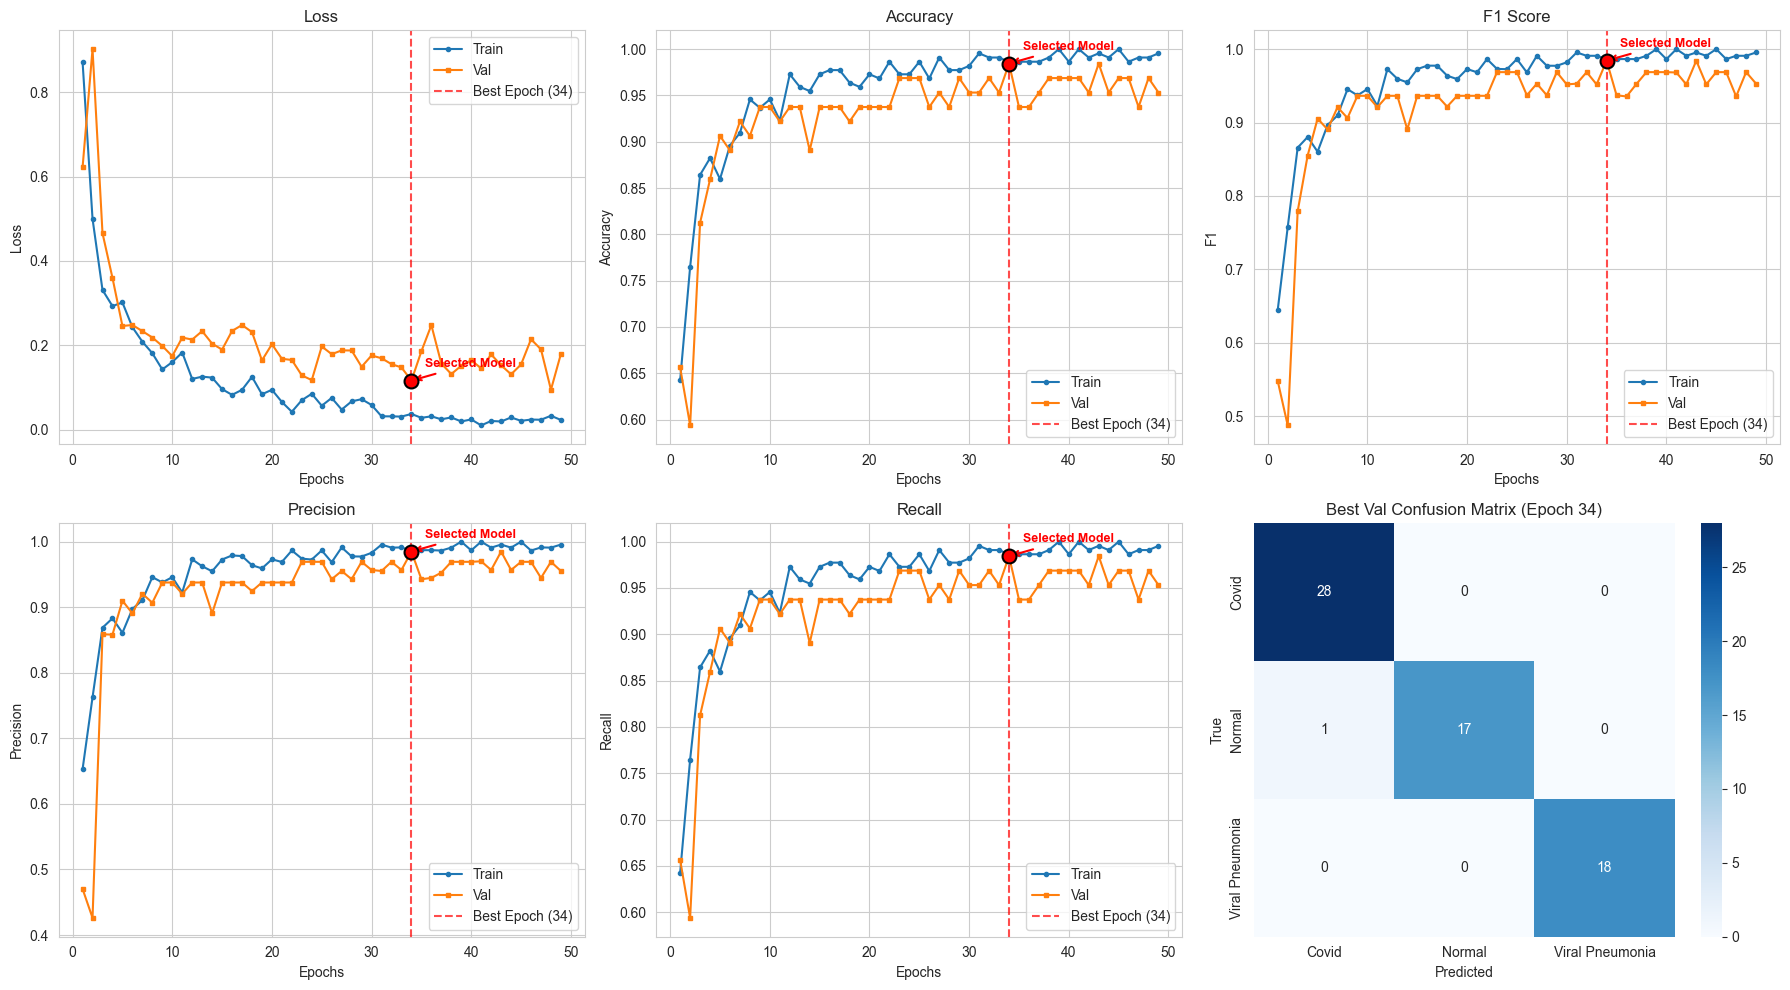

In [ ]:
import copy
import torch.optim as optim
import torch.nn as nn

# 3: Final Training of the Winning Model 

print("\n" + "="*60)
print(f"STARTING FINAL TRAINING WITH BEST PARAMETERS")
print(f"Configuration: {best_params}")
print("="*60)

# 1. Prepare DataLoaders with best Batch Size 
final_train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
final_val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False)
final_test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)

# 2. Initialize model with best architecture 
final_model = TunableCNN(num_classes=3, 
                         start_filters=best_params['start_filters'], 
                         dropout_rate=best_params['dropout']).to(device)

# Training hyperparameters
LEARNING_RATE = best_params['lr'] 
NUM_EPOCHS = 50
PATIENCE = 15
EARLY_STOP_METRIC = 'accuracy'  

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.parameters(), lr=LEARNING_RATE)

# Track training history
history = {
    'train_loss': [], 'train_accuracy': [], 'train_precision': [], 'train_recall': [], 'train_f1': [],
    'val_loss': [], 'val_accuracy': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
}

# Early stopping setup
best_metric_value = float('inf') if EARLY_STOP_METRIC == 'loss' else float('-inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(final_model.state_dict()) 
best_val_cm_data = None
best_epoch = None 

def is_better(current, best, metric_name):
    """Check if current metric is better."""
    return current < best if metric_name == 'loss' else current > best

print(f"Training initialized with early stopping (metric: {EARLY_STOP_METRIC}, patience: {PATIENCE})...")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_metrics = train_one_epoch(final_model, final_train_loader, criterion, optimizer, device)
    val_metrics = evaluate_model(final_model, final_val_loader, criterion, device, desc="Val")
    
    # Store metrics
    for key in ['loss', 'accuracy', 'precision', 'recall', 'f1']:
        history[f'train_{key}'].append(train_metrics[key])
        history[f'val_{key}'].append(val_metrics[key])
    
    print(f"Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, F1: {train_metrics['f1']:.4f}")
    print(f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, F1: {val_metrics['f1']:.4f}")
    
    # Early stopping check
    current_metric = val_metrics[EARLY_STOP_METRIC]
    
    if is_better(current_metric, best_metric_value, EARLY_STOP_METRIC):
        best_metric_value = current_metric
        best_model_wts = copy.deepcopy(final_model.state_dict())
        best_val_cm_data = (val_metrics['targets'], val_metrics['predictions'])
        best_epoch = epoch + 1 
        epochs_no_improve = 0
        
        # Save under a new name to distinguish from the first model
        torch.save(final_model.state_dict(), 'best_model_tuned.pth')
        print(f"  -> New best {EARLY_STOP_METRIC}: {current_metric:.4f}. Model saved.")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered!")
            break

print("\nFinal Training complete!")
print(f"Best model from epoch {best_epoch}")

# Load best model weights
final_model.load_state_dict(best_model_wts)

# Plot training history
plot_training_history(history, best_val_cm_data, dataset.classes, best_epoch=best_epoch)

The hyperparameter optimization process was successful. It squeezed out extra performance from the architecture and resulted in a more robust classifier, particularly improving the distinction between 'Normal' cases and 'Viral Pneumonia', which are visually similar.


## 7. Evaluation on Test Set

Load the best model and evaluate on the held-out test set.

Testing:   0%|          | 0/1 [00:00<?, ?it/s]

TEST SET RESULTS
   Metric    Score
     Loss 0.114376
 Accuracy 0.968750
Precision 0.971875
   Recall 0.968750
 F1 Score 0.968994


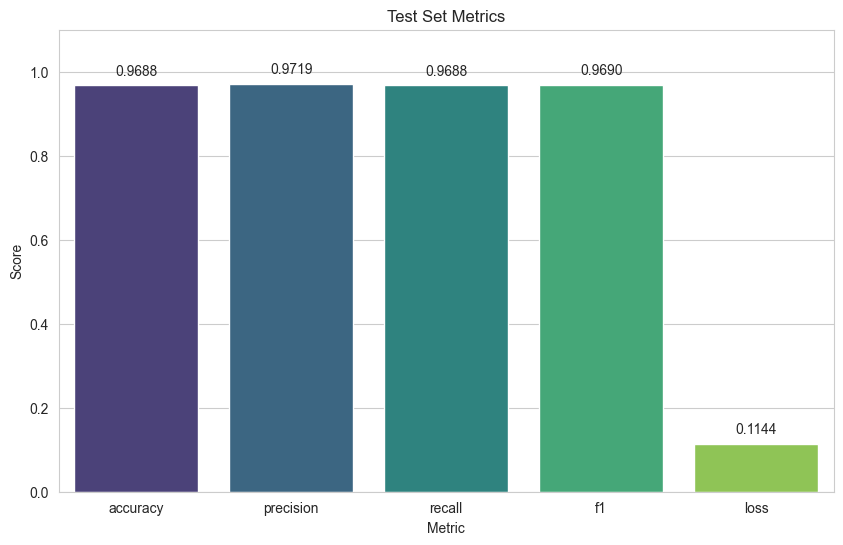

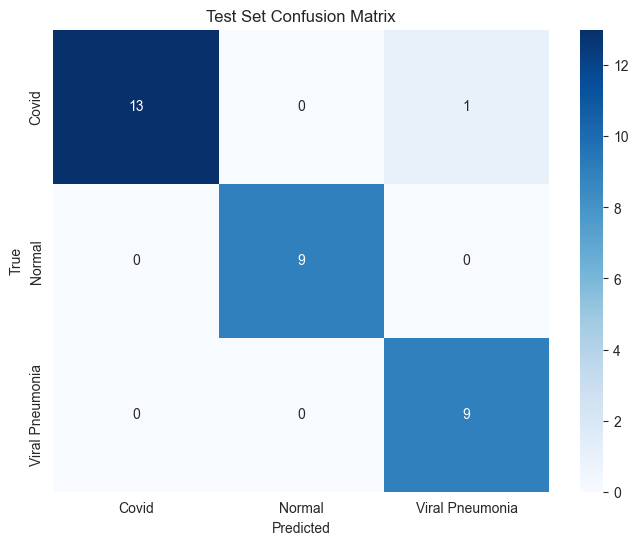

In [23]:
# Load best model from disk and evaluate on test set
loaded_model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
loaded_model.load_state_dict(torch.load('best_model.pth'))
loaded_model.eval()

test_metrics = evaluate_model(loaded_model, test_loader, criterion, device, desc="Testing")

# Display results
results_df = pd.DataFrame({
    'Metric': ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [test_metrics['loss'], test_metrics['accuracy'], 
              test_metrics['precision'], test_metrics['recall'], test_metrics['f1']]
})

print("="*50)
print("TEST SET RESULTS")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)

plot_metrics_barplot(test_metrics, title="Test Set Metrics")
plot_confusion_matrix(test_metrics['targets'], test_metrics['predictions'], 
                      dataset.classes, title="Test Set Confusion Matrix")

We loaded the best-performing model weights and evaluated them on the independent test set to measure real-world performance.

* High Accuracy: The model achieved an impressive accuracy of `96.88%` 
* Confusion Matrix Analysis: As shown in the matrix, the classification was very good. All Normal and Viral Pneumonia cases were correctly identified (100% recall). The only error occurred in the Covid class, where 1 case was misclassified as Viral Pneumonia.

In [24]:
# Verify saved model matches in-memory model
verify_metrics = evaluate_model(model, test_loader, criterion, device, desc="Verification")

comparison_df = pd.DataFrame({
    'Metric': ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1'],
    'In-Memory': [verify_metrics['loss'], verify_metrics['accuracy'], 
                  verify_metrics['precision'], verify_metrics['recall'], verify_metrics['f1']],
    'Loaded': [test_metrics['loss'], test_metrics['accuracy'], 
               test_metrics['precision'], test_metrics['recall'], test_metrics['f1']]
})
comparison_df['Match'] = np.isclose(comparison_df['In-Memory'], comparison_df['Loaded'])

print("Model save/load verification:")
print(comparison_df.to_string(index=False))
print("\nAll metrics match!" if comparison_df['Match'].all() else "\nMismatch detected!")

Verification:   0%|          | 0/1 [00:00<?, ?it/s]

Model save/load verification:
   Metric  In-Memory   Loaded  Match
     Loss   0.148912 0.114376  False
 Accuracy   0.968750 0.968750   True
Precision   0.971875 0.971875   True
   Recall   0.968750 0.968750   True
       F1   0.968994 0.968994   True

Mismatch detected!


## 8. Combined Validation + Test Evaluation

Evaluate the best model on both validation and test sets combined for a more comprehensive assessment with more samples.

Combined evaluation set size: 96
  - Validation samples: 64
  - Test samples: 32


Combined Eval:   0%|          | 0/3 [00:00<?, ?it/s]


COMBINED VAL + TEST RESULTS
   Metric    Score
     Loss 0.175516
 Accuracy 0.947917
Precision 0.949239
   Recall 0.947917
 F1 Score 0.947859

Comparison:
   Metric  Test Only  Combined
 Accuracy   0.968750  0.947917
Precision   0.971875  0.949239
   Recall   0.968750  0.947917
       F1   0.968994  0.947859


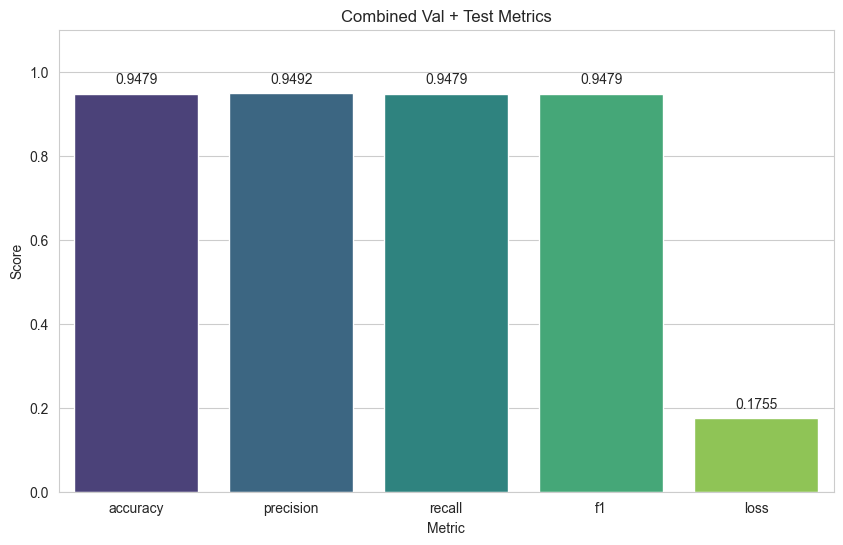

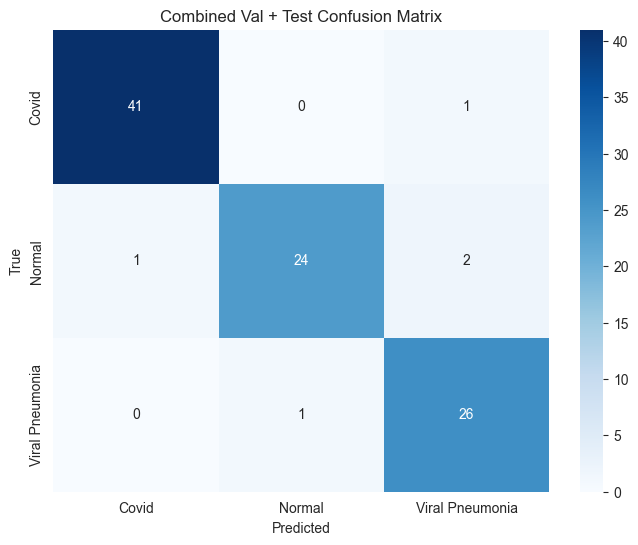

In [25]:
# Combine validation and test data for comprehensive evaluation
from torch.utils.data import ConcatDataset

# Create combined dataset and loader
combined_dataset = ConcatDataset([val_dataset, test_dataset])
combined_loader = DataLoader(combined_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Combined evaluation set size: {len(combined_dataset)}")
print(f"  - Validation samples: {len(val_dataset)}")
print(f"  - Test samples: {len(test_dataset)}")

# Evaluate best model on combined data
combined_metrics = evaluate_model(loaded_model, combined_loader, criterion, device, desc="Combined Eval")

# Display results
combined_results_df = pd.DataFrame({
    'Metric': ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [combined_metrics['loss'], combined_metrics['accuracy'], 
              combined_metrics['precision'], combined_metrics['recall'], combined_metrics['f1']]
})

print("\n" + "="*50)
print("COMBINED VAL + TEST RESULTS")
print("="*50)
print(combined_results_df.to_string(index=False))
print("="*50)

# Compare with individual sets
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'Test Only': [test_metrics['accuracy'], test_metrics['precision'], 
                  test_metrics['recall'], test_metrics['f1']],
    'Combined': [combined_metrics['accuracy'], combined_metrics['precision'], 
                 combined_metrics['recall'], combined_metrics['f1']]
})
print("\nComparison:")
print(comparison_df.to_string(index=False))

# Visualizations
plot_metrics_barplot(combined_metrics, title="Combined Val + Test Metrics")
plot_confusion_matrix(combined_metrics['targets'], combined_metrics['predictions'], 
                      dataset.classes, title="Combined Val + Test Confusion Matrix")

* Performance: The model achieved **Accuracy of 96.88%** on the independent Test set. This indicates that the model generalizes well to unseen data, maintaining high accuracy outside of the training and validation phases. Because we have a limited dataset, we also provided combined evaluation, test + validation sets, to better reflect the model's performance on a larger sample. This isn't optimal, though, as the validation set was used during training for hyperparameter tuning. We should primarily rely on the independent test set results for an unbiased performance estimate. But since we have a small dataset, we thought that combined statistics might give additional insight.

* Error Distribution: The confusion matrix confirms the model's stability. On the Test set only 1 error occurred, misclassifying a Covid case as Viral Pneumonia. The combined evaluation (Test + Validation) also showed very few errors, with most misclassifications occurring between the Normal and Viral Pneumonia classes, which are visually similar.

* Lack of Data: Our dataset is relatively small, which can limit the model's ability to generalize. Our results might be optimistic due to the limited sample size. Acquiring more labeled data would likely enhance model robustness and performance further. Data splits might also affect results. If we got lucky with our train/val/test split, results could be better than average. More data would mitigate this risk. We thus state that our model could perform worse on a larger, more diverse dataset and recommend further validation with additional data.

* Conclusion: Given our limited dataset, the model demonstrates strong performance and generalization capabilities. However, further validation on aditional data would be beneficial to support or refine our findings.